Import the libraries.

In [39]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


Load the dataset.

In [40]:
df = pd.read_csv('../Datasets/churn_modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [41]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Value count to see the data is disbalanced.

In [42]:
df['Geography'].value_counts(), df['Exited'].value_counts()

(Geography
 France     5014
 Germany    2509
 Spain      2477
 Name: count, dtype: int64,
 Exited
 0    7963
 1    2037
 Name: count, dtype: int64)

One-hot encoding on categorical column.

In [ ]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int )
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


Train test split and scaling the data.

In [44]:
X = df.drop('Exited', axis=1)
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

Make MLP of 3 layers.

In [53]:
model = Sequential()
model.add(Dense(11,activation='sigmoid',input_dim=11)) # Input layer with 11 neurons and sigmoid activation function.
model.add(Dense(11,activation='sigmoid')) # Hidden layer with 11 neurons and sigmoid activation function.
model.add(Dense(1,activation='sigmoid')) # Output layer with 1 neuron and sigmoid activation function.

/home/hardik/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Summary for the MLP, the number of parameters.

In [46]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

Prepare the model and train on scaled data.

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Compile the model with Adam optimizer, binary cross-entropy loss function, and accuracy metric.
history = model.fit(X_train_trf, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7650 - loss: 0.5539 - val_accuracy: 0.7987 - val_loss: 0.4903
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4893 - val_accuracy: 0.7987 - val_loss: 0.4727
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.4757 - val_accuracy: 0.7987 - val_loss: 0.4592
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7934 - loss: 0.4632 - val_accuracy: 0.7987 - val_loss: 0.4459
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7936 - loss: 0.4516 - val_accuracy: 0.8031 - val_loss: 0.4352
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7980 - loss: 0.4425 - val_accuracy: 0.8175 - val_loss: 0.4275
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8091 - loss: 0.4362 - val_accuracy: 0.8238 - val_loss: 0.4223
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8153 - loss: 0.4316 - val_accuracy: 0.8244

Find y predicted and find accuracy score.

In [48]:
y_log = model.predict(X_test_trf)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.04108173],
       [0.03606253],
       [0.14357373],
       ...,
       [0.7976544 ],
       [0.13429245],
       [0.3120022 ]], shape=(2000, 1), dtype=float32)

In [49]:
y_pred = y_log.argmax(axis=1)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [50]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8035

Plots for accuracy and loss.

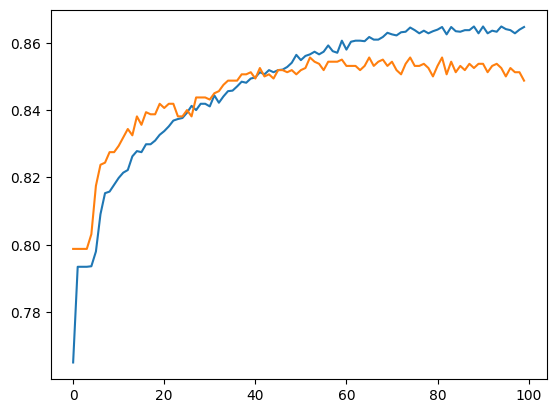

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.show()

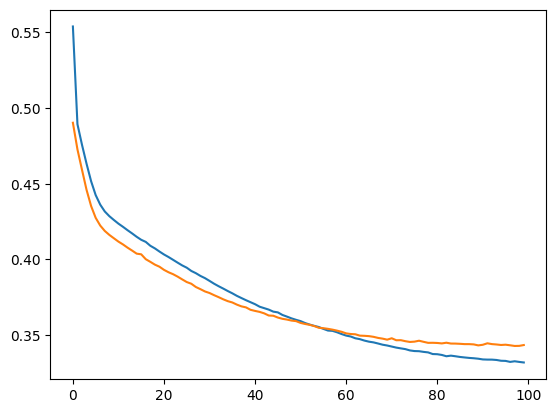

In [52]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.show()